In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('Social_Network_Ads_SVM.csv')
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [4]:
print(data.isnull().sum())

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [5]:
x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.25, random_state = 42
)

In [7]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [8]:
from sklearn.svm import SVC

classifier = SVC(kernel = 'linear', random_state = 42)
classifier.fit(x_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [9]:
y_pred = classifier.predict(x_test)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy : ", accuracy_score(y_pred, y_test))

cm = confusion_matrix(y_pred, y_test)
print("Confusion Matrix : \n", cm)

Accuracy :  0.86
Confusion Matrix : 
 [[61 12]
 [ 2 25]]


## Decsion Bounday

C:\Users\faisa\AppData\Local\Temp\ipykernel_15948\3173438834.py:21: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


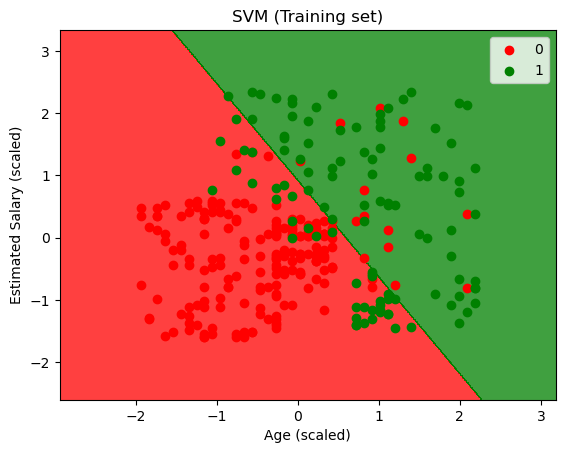

In [11]:
from matplotlib.colors import ListedColormap

X_set, y_set = x_train, y_train

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('SVM (Training set)')
plt.xlabel('Age (scaled)')
plt.ylabel('Estimated Salary (scaled)')
plt.legend()
plt.show()

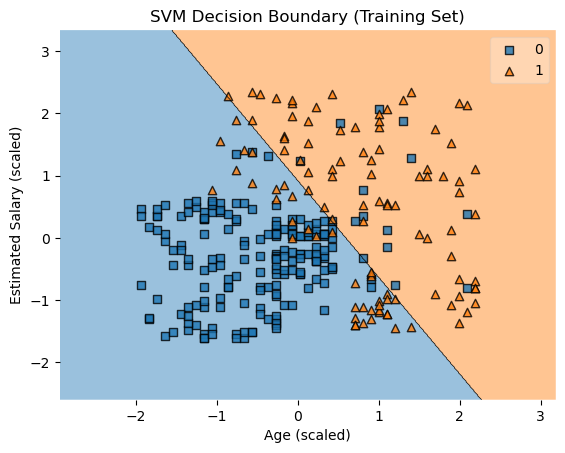

In [13]:
from mlxtend.plotting import plot_decision_regions

plot_decision_regions(x_train, y_train, clf=classifier)

plt.title("SVM Decision Boundary (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.show()